# Data

## Dataset Overview

In [24]:
library(ggplot2)
library(tidyr)
library(dplyr)
source("config.R")

In [7]:
cookiecat.data <- read.csv(COOKIECATS_DATA)

str(cookiecat.data)

'data.frame':	90189 obs. of  5 variables:
 $ userid        : int  116 337 377 483 488 540 1066 1444 1574 1587 ...
 $ version       : chr  "gate_30" "gate_30" "gate_40" "gate_40" ...
 $ sum_gamerounds: int  3 38 165 1 179 187 0 2 108 153 ...
 $ retention_1   : logi  FALSE TRUE TRUE FALSE TRUE TRUE ...
 $ retention_7   : logi  FALSE FALSE FALSE FALSE TRUE TRUE ...


In [ ]:
summary(cookiecat.data)

     userid          version          sum_gamerounds     retention_1    
 Min.   :    116   Length:90189       Min.   :    0.00   Mode :logical  
 1st Qu.:2512230   Class :character   1st Qu.:    5.00   FALSE:50036    
 Median :4995815   Mode  :character   Median :   16.00   TRUE :40153    
 Mean   :4998412                      Mean   :   51.87                  
 3rd Qu.:7496452                      3rd Qu.:   51.00                  
 Max.   :9999861                      Max.   :49854.00                  
 retention_7    
 Mode :logical  
 FALSE:73408    
 TRUE :16781    
                
                
                

In [9]:
check_missing <- function(df, df.name = "") {
  missing.idx <- which(!complete.cases(df))
  cat(df.name, ": Found", length(missing.idx), "missing rows\n")
  if (length(missing.idx) > 0) print(df[missing.idx, ], row.names = FALSE)
  invisible(missing.idx)
}

check_missing(cookiecat.data, "cookiecat.data")

cookiecat.data : Found 0 missing rows


# Exploratory Data Analysis

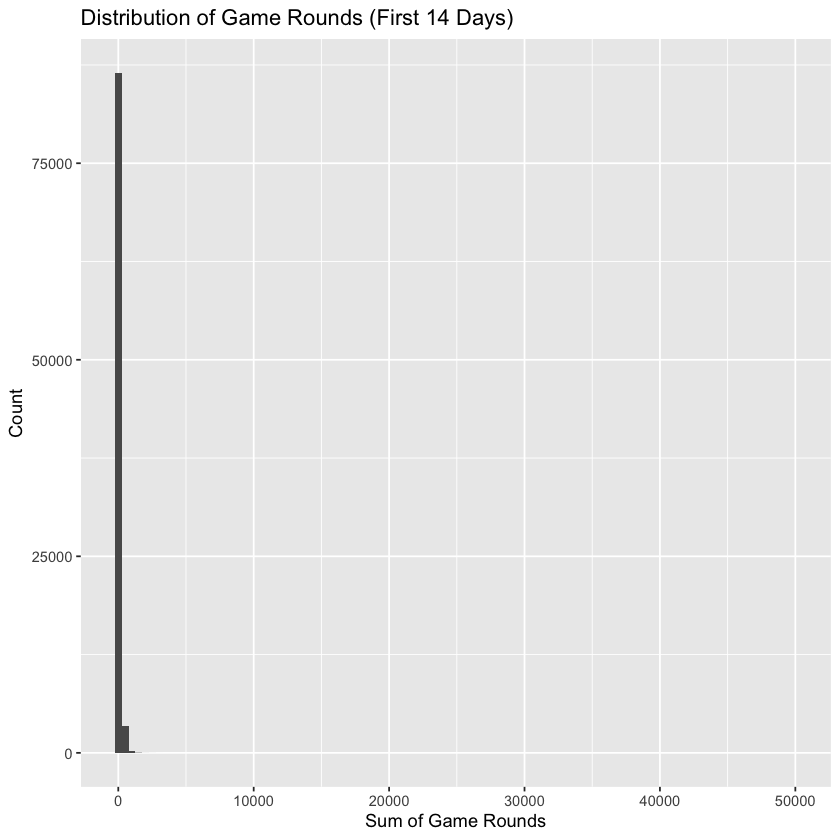

In [19]:
ggplot(cookiecat.data, aes(x = sum_gamerounds)) +
  geom_histogram(bins = 100) +
  labs(title = "Distribution of Game Rounds (First 14 Days)",
       x = "Sum of Game Rounds",
       y = "Count")

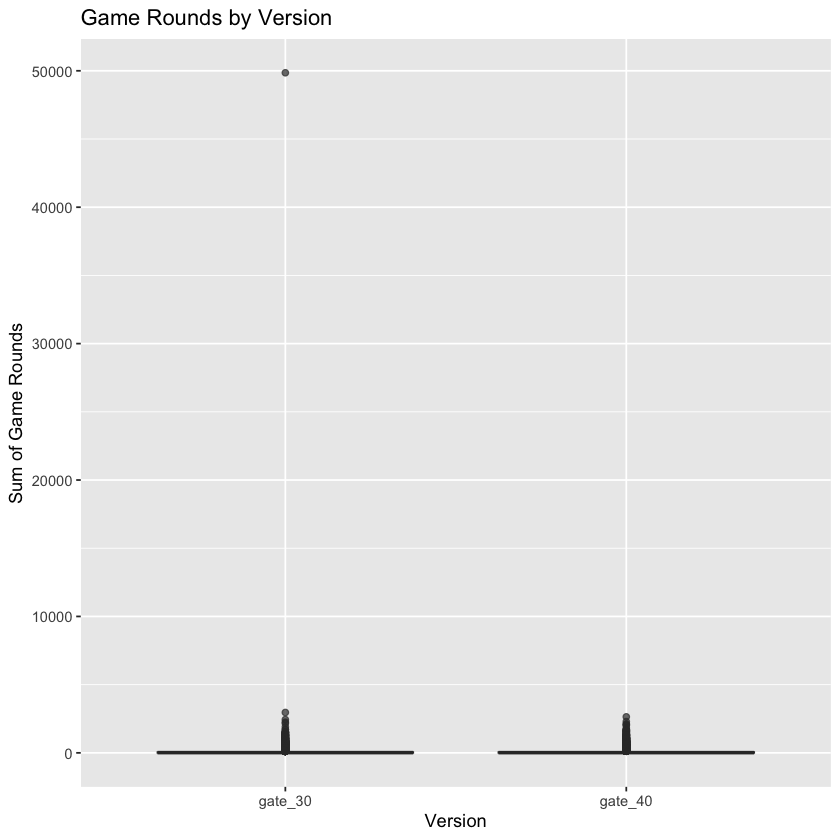

In [20]:
ggplot(cookiecat.data, aes(x = version, y = sum_gamerounds)) +
  geom_boxplot(alpha = 0.7) +
  labs(title = "Game Rounds by Version",
       x = "Version",
       y = "Sum of Game Rounds") +
  theme(legend.position = "none")


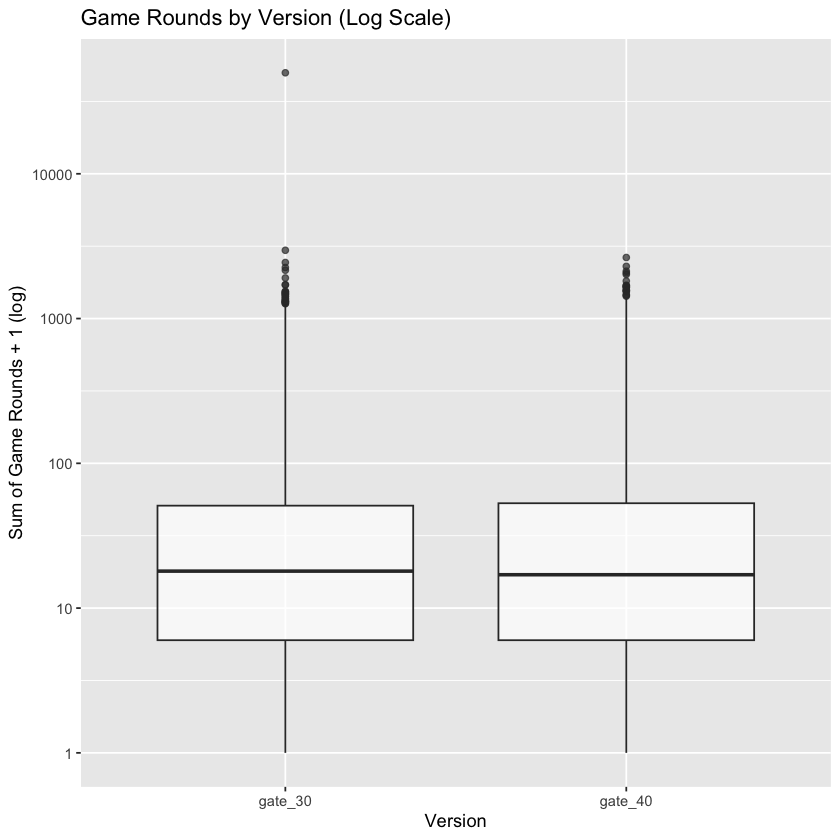

In [22]:
ggplot(cookiecat.data, aes(x = version, y = sum_gamerounds + 1)) +
  geom_boxplot(alpha = 0.7) +
  scale_y_log10() +
  labs(title = "Game Rounds by Version (Log Scale)",
       x = "Version",
       y = "Sum of Game Rounds + 1 (log)")


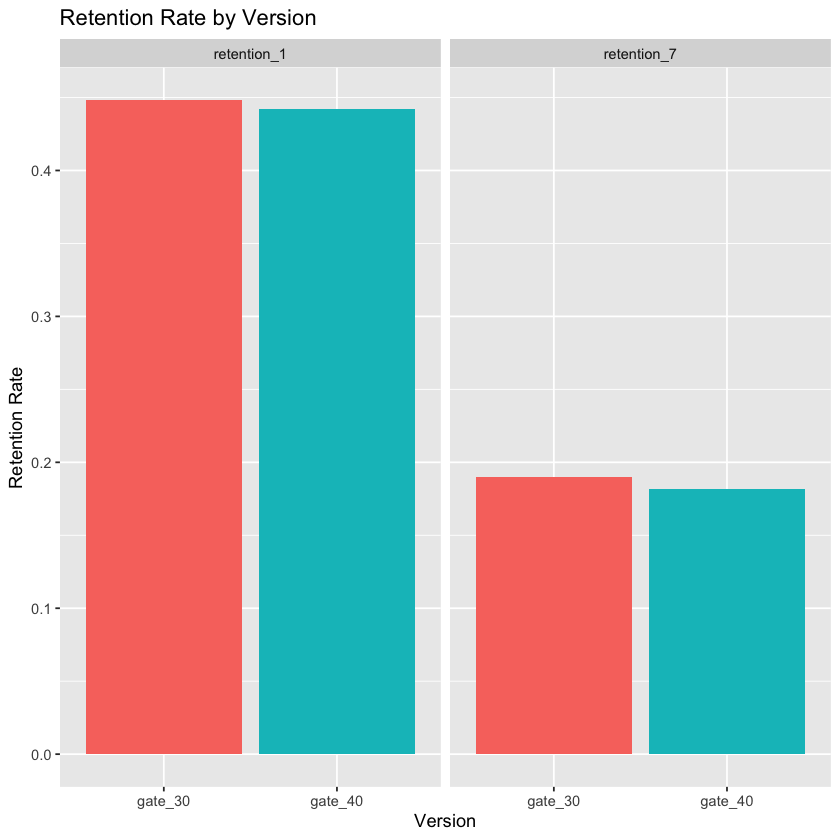

In [26]:
cookiecat.data %>%
  pivot_longer(cols = c(retention_1, retention_7),
               names_to = "retention_type",
               values_to = "retained") %>%
  group_by(version, retention_type) %>%
  summarise(retention_rate = mean(retained), .groups = "drop") %>%
  ggplot(aes(x = version, y = retention_rate, fill = version)) +
  geom_bar(stat = "identity") +
  facet_wrap(~retention_type) +
  labs(title = "Retention Rate by Version",
       x = "Version", y = "Retention Rate") +
  theme(legend.position = "none")
